# Evaluation and Demo

Import libraries

In [1]:
import torch
from torchinfo import summary
import yaml
from training import Trainer
import os
from utils import get_data
from accelerate import Accelerator # for multigpu
from dotenv import load_dotenv
load_dotenv()  # take environment variables from .env file

# accelerator for multigpu
accelerator = Accelerator()

##### Datasets and splits

In [2]:
# load and split dataset
from torchvision import transforms
from gripper_data import GripperDataset
from gripper_data_ref import GripperDatasetReference
from utils import split_dataset
from torch.utils.data import DataLoader

BATCH_SIZE = 32
torch.manual_seed(6) # for reproducibility

FULL_DATASET_PATH = os.getenv("BIG_DATASET_PATH") 
TOY_DATASET_PATH = os.getenv("DATASET_PATH")

FULL_DATASET_SPLIT = [70000,20000,10000] # train, val, test
TOY_DATASET_SPLIT = [8000, 2000, 300] # train, val, test

# Preprocessing transforms
top_img_shape = [720, 1280] # original image shape
resize_factor = 16
resize_shape = [int(x//resize_factor) for x in top_img_shape]
preprocess = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize(resize_shape),
        ])


Normal datasets

In [3]:
# -- Full dataset --
dataset = GripperDataset(abs_path=FULL_DATASET_PATH, 
                        transform=preprocess,
                        images_to_load=["Images"])        
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, FULL_DATASET_SPLIT)
val_dataset_early_stopping, val_dataset_2 = split_dataset(val_dataset, [10000,10000])

print(f"\nOriginal dataset size: {len(dataset)}")
print(f"- Len train dataset: {len(train_dataset)}",
            f"- Len val dataset: {len(val_dataset)}",
            f"  - Len val dataset for early stopping: {len(val_dataset_early_stopping)}",
            f"  - Len val dataset for comparison: {len(val_dataset_2)}",
            f"- Len test dataset: {len(test_dataset)}", sep="\n")


# -- Toy dataset --
toy_dataset = GripperDataset(abs_path=TOY_DATASET_PATH, 
                        transform=preprocess,
                        images_to_load=["Images"])        
toy_train_dataset, toy_val_dataset, toy_test_dataset = torch.utils.data.random_split(toy_dataset, TOY_DATASET_SPLIT)

print(f"\nToy dataset size: {len(toy_train_dataset) + len(toy_val_dataset) + len(toy_test_dataset)}")
print(f"- Len toy train dataset: {len(toy_train_dataset)}",
            f"- Len toy val dataset: {len(toy_val_dataset)}",
            f"- Len toy test dataset: {len(toy_test_dataset)}", sep="\n")


# DataLoaders

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
toy_test_loader = DataLoader(toy_test_dataset, batch_size=BATCH_SIZE, shuffle=False)


Original dataset size: 100000
- Len train dataset: 70000
- Len val dataset: 20000
  - Len val dataset for early stopping: 10000
  - Len val dataset for comparison: 10000
- Len test dataset: 10000

Toy dataset size: 10300
- Len toy train dataset: 8000
- Len toy val dataset: 2000
- Len toy test dataset: 300


Datasets with 1 reference image

In [4]:
# -- Full dataset --
ref_dataset = GripperDatasetReference(abs_path=FULL_DATASET_PATH, 
                        transform=preprocess,
                        images_to_load=["Images"])        

ref_train_dataset, ref_val_dataset, ref_test_dataset = torch.utils.data.random_split(ref_dataset, FULL_DATASET_SPLIT)
ref_val_dataset_early_stopping, ref_val_dataset_2 = split_dataset(ref_val_dataset, [10000,10000])

print(f"\nOriginal dataset with 1 reference size: {len(ref_dataset)}")
print(f"- Len train dataset: {len(ref_train_dataset)}",
            f"- Len val dataset: {len(ref_val_dataset)}",
            f"  - Len val dataset for early stopping: {len(ref_val_dataset_early_stopping)}",
            f"  - Len val dataset for comparison: {len(ref_val_dataset_2)}",
            f"- Len test dataset: {len(ref_test_dataset)}", sep="\n")


# -- Toy dataset --
ref_toy_dataset = GripperDatasetReference(abs_path=TOY_DATASET_PATH, 
                        transform=preprocess,
                        images_to_load=["Images"])        

ref_toy_train_dataset, ref_toy_val_dataset, ref_toy_test_dataset = torch.utils.data.random_split(ref_toy_dataset, TOY_DATASET_SPLIT)

print(f"\nToy dataset with 1 reference size: {len(ref_toy_train_dataset) + len(ref_toy_val_dataset) + len(ref_toy_test_dataset)}")
print(f"- Len toy train dataset: {len(ref_toy_train_dataset)}",
            f"- Len toy val dataset: {len(ref_toy_val_dataset)}",
            f"- Len toy test dataset: {len(ref_toy_test_dataset)}", sep="\n")


# DataLoaders
ref_test_loader = DataLoader(ref_test_dataset, batch_size=BATCH_SIZE, shuffle=False)
ref_toy_test_loader = DataLoader(ref_toy_test_dataset, batch_size=BATCH_SIZE, shuffle=False)



Original dataset with 1 reference size: 100000
- Len train dataset: 70000
- Len val dataset: 20000
  - Len val dataset for early stopping: 10000
  - Len val dataset for comparison: 10000
- Len test dataset: 10000

Toy dataset with 1 reference size: 10300
- Len toy train dataset: 8000
- Len toy val dataset: 2000
- Len toy test dataset: 300


Datasets with 10 reference images

In [5]:
# -- Full dataset --
NUM_REFERENCES = 10
dataset_10ref = GripperDatasetReference(abs_path=FULL_DATASET_PATH, 
                        transform=preprocess,
                        images_to_load=["Images"])   
dataset_10ref.set_references(num_references=NUM_REFERENCES)     

train_dataset_10ref, val_dataset_10ref, test_dataset_10ref = torch.utils.data.random_split(dataset_10ref, FULL_DATASET_SPLIT)
val_dataset_early_stopping_10ref, val_dataset_2_10ref = split_dataset(val_dataset_10ref, [10000,10000])
print(f"\nOriginal dataset with 10 references size: {len(dataset_10ref)}")
print(f"- Len train dataset: {len(train_dataset_10ref)}",
            f"- Len val dataset: {len(val_dataset_10ref)}",
            f"  - Len val dataset for early stopping: {len(val_dataset_early_stopping_10ref)}",
            f"  - Len val dataset for comparison: {len(val_dataset_2_10ref)}",
            f"- Len test dataset: {len(test_dataset_10ref)}", sep="\n")


# -- Toy dataset --
toy_dataset_10ref = GripperDatasetReference(abs_path=TOY_DATASET_PATH, 
                        transform=preprocess,
                        images_to_load=["Images"])        
toy_dataset_10ref.set_references(num_references=NUM_REFERENCES)
toy_train_dataset_10ref, toy_val_dataset_10ref, toy_test_dataset_10ref = torch.utils.data.random_split(toy_dataset_10ref, TOY_DATASET_SPLIT)
toy_train_dataset_10ref, toy_val_dataset_10ref, toy_test_dataset_10ref = torch.utils.data.random_split(toy_dataset_10ref, TOY_DATASET_SPLIT)

print(f"\nToy dataset with 10 references size: {len(toy_train_dataset_10ref) + len(toy_val_dataset_10ref) + len(toy_test_dataset_10ref)}")
print(f"- Len toy train dataset: {len(toy_train_dataset_10ref)}",
            f"- Len toy val dataset: {len(toy_val_dataset_10ref)}",
            f"- Len toy test dataset: {len(toy_test_dataset_10ref)}", sep="\n")


# DataLoaders
test_loader_10ref = DataLoader(test_dataset_10ref, batch_size=BATCH_SIZE, shuffle=False)
toy_test_loader_10ref = DataLoader(toy_test_dataset_10ref, batch_size=BATCH_SIZE, shuffle=False)


Selected 10 reference indices.
Automatically selected reference index: [7758, 3091, 33458, 94676, 10228, 35911, 83289, 46956, 3866, 74232]

Original dataset with 10 references size: 100000
- Len train dataset: 70000
- Len val dataset: 20000
  - Len val dataset for early stopping: 10000
  - Len val dataset for comparison: 10000
- Len test dataset: 10000
Selected 10 reference indices.
Automatically selected reference index: [3759, 9116, 8565, 5236, 1665, 1836, 5064, 6537, 1185, 8634]

Toy dataset with 10 references size: 10300
- Len toy train dataset: 8000
- Len toy val dataset: 2000
- Len toy test dataset: 300


##### Visualization

In [15]:
from matplotlib import pyplot as plt
def plot_input_vs_reconstruction(img, reconstruction):
    fig, axs = plt.subplots(1,2, figsize=(12,4))
    axs[0].imshow(img.permute(1,2,0))
    axs[0].set_title("Image")
    axs[0].axis('off')
    axs[1].imshow(reconstruction.permute(1,2,0))
    axs[1].set_title("Reconstructed Image")
    axs[1].axis('off')
    plt.show()

def plot_reference_vs_reconstruction_vs_target(reference, reconstruction, target):
    fig, axs = plt.subplots(1,3, figsize=(16,4))
    axs[0].imshow(reference.permute(1,2,0))
    axs[0].set_title("Reference Image")
    axs[0].axis('off')
    axs[1].imshow(reconstruction.permute(1,2,0))
    axs[1].set_title("Reconstructed Image")
    axs[1].axis('off')
    axs[2].imshow(target.permute(1,2,0))
    axs[2].set_title("Target Image")
    axs[2].axis('off')
    plt.show()


def show_sample_input_vs_reconstruction(dataset, model: Trainer, idx: int):
    batch = list(dataset[idx])
    images, labels = batch
    for i in range(len(batch)):
        batch[i] = batch[i].unsqueeze(0)  # add batch dimension
    reconstruction, losses = model.evaluation_step(batch, verbose=True)
    reconstruction = reconstruction.clamp(0, 1).detach()

    print(f"Robot configuration x={labels[0]:.3f}, y={labels[1]:.3f}, z={labels[2]:.3f}, r={labels[3]:.3f}, g={labels[4]:.3f}")
    plot_input_vs_reconstruction(images, reconstruction[0])

def show_sample_reference_vs_reconstruction_vs_target(dataset, model: Trainer, idx: int):
    batch = list(dataset[idx])
    images, labels, references, ref_labels = batch
    for i in range(len(batch)):
        batch[i] = batch[i].unsqueeze(0)  # add batch dimension
    reconstruction, losses = model.evaluation_step(batch, verbose=True)
    reconstruction = reconstruction.clamp(0, 1).detach() 

    print(f"Robot configuration x={labels[0]:.3f}, y={labels[1]:.3f}, z={labels[2]:.3f}, r={labels[3]:.3f}, g={labels[4]:.3f}")
    plot_reference_vs_reconstruction_vs_target(references, reconstruction[0], images)


from ipywidgets import interact
def slider_input_vs_reconstruction(dataset, model: Trainer):
    @interact(idx=(0, len(dataset)-1))
    def slider_with_plots(idx=0):
       show_sample_input_vs_reconstruction(dataset, model, idx)


def slider_reference_vs_reconstruction_vs_target(dataset, model: Trainer):
    @interact(idx=(0, len(dataset)-1))
    def slider_with_plots(idx=0):
        show_sample_reference_vs_reconstruction_vs_target(dataset, model, idx)

# Encoder

# Decoder

## Fourier MLP decoder

In [3]:
decoder_type = "fourier_mlp_decoder"
trained_decoders = os.listdir(os.path.join("trained_models", decoder_type))
print("Available trained decoders:", *trained_decoders, sep="\n- ")

Available trained decoders:
- debug_config_train32_val32_batch32_xyzrg
- debug_datapath_train32_val32_batch32_xyzrg
- debug_freq_train32_val32_batch32_xyzrg
- debug_logger_train32_val32_batch32_xyzrg
- debug_lpips_train32_val32_batch32_xyzrg
- debug_reconstruction_train32_val32_batch32_xyzrg
- debug_save_load_train32_val32_batch32_xyzrg
- debug_train32_val32_batch32_xyzrg
- freq_32_train32_val32_batch32_xyzrg
- freq_64_train32_val32_batch32_xyzrg
- MSE_val10000_batch32_xyzrg_cluster
- train32_val32_batch32_xyzrg


#### Decoder trained with MSE Loss

#### Decoder trained with LPIPS Loss

In [ ]:
MODEL_TO_LOAD = "train32_val32_batch32_xyzrg"

In [14]:
from architecture import FourierMlpDecoder

# load trained model
decoder = FourierMlpDecoder(
    model_name=MODEL_TO_LOAD,
    accelerator=accelerator,
    config=config, # TODO: local config
)
decoder.load_model()
# from accelerate import load_checkpoint_in_model
# load_checkpoint_in_model(decoder,
#                          os.path.join("fourier_mlp_decoder", "debug_save_load_train32_val32_batch32_xyzrg"), 
# )#device_map={"":decoder.device})
decoder = accelerator.prepare(decoder)
summary(decoder, input_size=(1, len(config["model"]["dimensions_to_learn"])))
decoder.eval()
decoder_trainer = Trainer(decoder, config)

Train batch-loss MSE: 0.020593509078025818
Train batch-loss RMSE: 0.1435043869643915
Output shape: (32, 3, 45, 80)
Robot configuration x=0.460, y=0.500, z=0.050, r=0.000, g=1.000


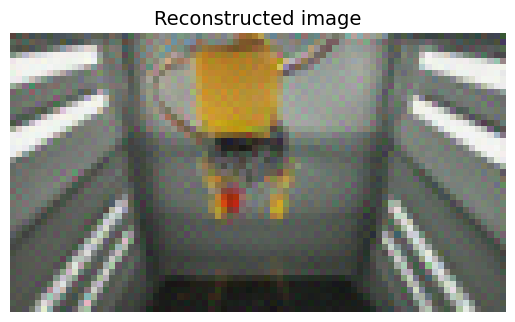

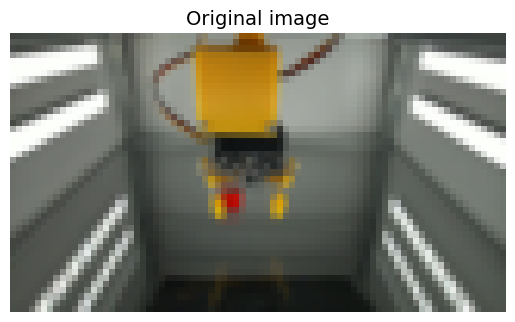

In [15]:
batch = next(iter(train_loader))
images, labels = batch

# inference on train set
output, loss = decoder_trainer._inference_step(batch)
loss = loss.item()
output = output.detach().numpy()

print("Train batch-loss MSE:", loss)
print("Train batch-loss RMSE:", loss**0.5)
print("Output shape:", output.shape)
# plot original and reconstructed images
from gripper_data import plot_image
num_sample = 8
print(f"Robot configuration x={labels[num_sample,0]:.3f}, y={labels[num_sample,1]:.3f}, z={labels[num_sample,2]:.3f}, r={labels[num_sample,3]:.3f}, g={labels[num_sample,4]:.3f}")
plot_image(output[num_sample], title="Reconstructed image")
plot_image(images[num_sample], title="Original image")

 inference on test set

Inference on test set:
Test loss MSE: 0.1273220181465149
Test loss RMSE: 0.35682210994627966
Output shape: (32, 3, 45, 80)
Robot configuration x=0.810, y=0.500, z=0.289, r=0.000, g=1.000


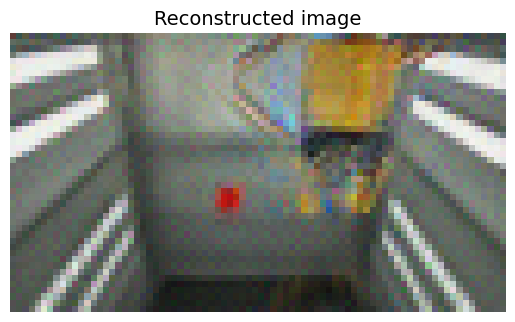

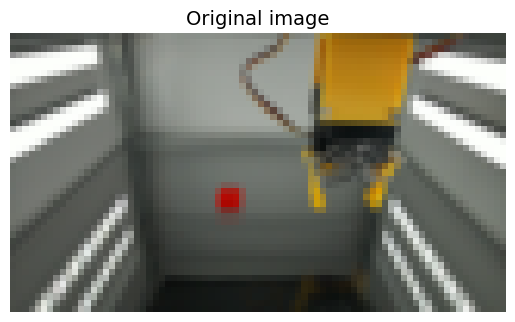

In [18]:
batch = next(iter(test_loader))
images, labels = batch

# inference on train set
output, loss = decoder_trainer._inference_step(batch)
loss = loss.item()
output = output.detach().numpy()

print("Inference on test set:")
print("Test loss MSE:", loss)
print("Test loss RMSE:", loss**0.5)
print("Output shape:", output.shape)
# plot original and reconstructed images
from gripper_data import plot_image
num_sample = 8
print(f"Robot configuration x={labels[num_sample,0]:.3f}, y={labels[num_sample,1]:.3f}, z={labels[num_sample,2]:.3f}, r={labels[num_sample,3]:.3f}, g={labels[num_sample,4]:.3f}")
plot_image(output[num_sample], title="Reconstructed image")
plot_image(images[num_sample], title="Original image")


In [4]:
MODEL_TO_LOAD = "MSE_val10000_batch32_xyzrg_cluster"

In [5]:
from architecture import FourierMlpDecoder

model_path = os.path.join("trained_models", decoder_type, MODEL_TO_LOAD)
config_file = os.path.join("trained_models", decoder_type, MODEL_TO_LOAD, "config.yaml")
with open(config_file, "r") as f:
    config = yaml.safe_load(f)
    config["data"]["dataset_path"] = os.getenv("DATASET_PATH_BIG")

# dataset
train_loader, val_loader, test_loader = get_data(config)

# load trained model
decoder = FourierMlpDecoder(
    model_name=MODEL_TO_LOAD,
    accelerator=accelerator,
    config=config, 
)
decoder.load_model()
# from accelerate import load_checkpoint_in_model
# load_checkpoint_in_model(decoder,
#                          os.path.join("fourier_mlp_decoder", "debug_save_load_train32_val32_batch32_xyzrg"), 
# )#device_map={"":decoder.device})
decoder = accelerator.prepare(decoder)
# decoder.summary(input_size=[(1, 3, 45, 80), (1, len(config["model"]["dimensions_to_learn"]))])
decoder.eval()
decoder_trainer = Trainer(decoder, config)

Train batch-loss MSE: 0.002905134577304125
Train batch-loss RMSE: 0.053899300341508374
Output shape: (32, 3, 45, 80)
Robot configuration x=0.676, y=0.836, z=0.433, r=0.117, g=0.322


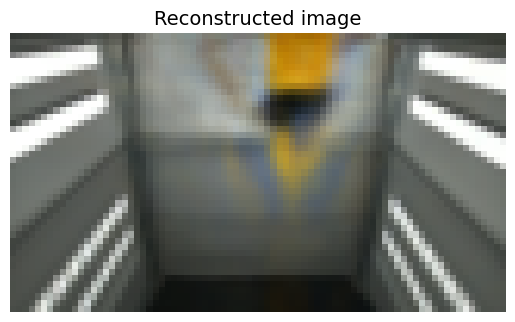

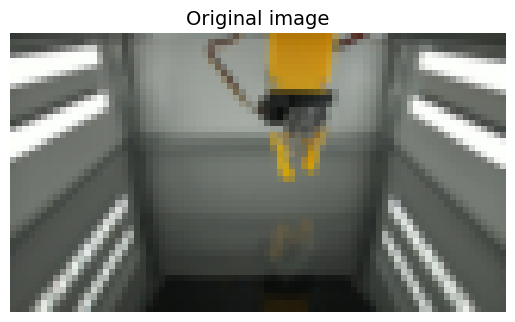

In [11]:
batch = next(iter(train_loader))
images, labels = batch

# inference on train set
output, loss = decoder_trainer._inference_step(batch)
loss = loss.item()
output = output.clamp(0, 1).detach().numpy()

print("Train batch-loss MSE:", loss)
print("Train batch-loss RMSE:", loss**0.5)
print("Output shape:", output.shape)
# plot original and reconstructed images
from gripper_data import plot_image
num_sample = 10
print(f"Robot configuration x={labels[num_sample,0]:.3f}, y={labels[num_sample,1]:.3f}, z={labels[num_sample,2]:.3f}, r={labels[num_sample,3]:.3f}, g={labels[num_sample,4]:.3f}")
plot_image(output[num_sample], title="Reconstructed image")
plot_image(images[num_sample], title="Original image")

## Conditioned UNet

In [7]:
from conditioned_UNet import UNetWithFiLM
dir = "trained_models_cluster"
decoder_type = "u_net_with_fi_l_m"

# print(f"Current dir \"{os.path.abspath(os.curdir)}\"")
trained_decoders = os.listdir(os.path.join(dir, decoder_type))
print("Available trained Conditioned UNet with FiLM:", *trained_decoders, sep="\n- ")

Available trained Conditioned UNet with FiLM:
- cnet_1ref_val10000_batch32_xyzrg
- unet_10ref_val10000_batch32_xyzrg


### cUNet with 1 reference

The cUNet uses as input always the same single reference image for all samples.

In [8]:
MODEL_TO_LOAD = "cnet_1ref_val10000_batch32_xyzrg"

In [9]:
# load model config
model_path = os.path.join(dir, decoder_type, MODEL_TO_LOAD)
config_file = os.path.join(dir, decoder_type, MODEL_TO_LOAD, "config.yaml")
with open(config_file, "r") as f:
    config = yaml.safe_load(f)

# load trained model
unet_1ref = UNetWithFiLM(
    model_name=MODEL_TO_LOAD,
    accelerator=accelerator,
    config=config, 
)
unet_1ref.load_model(model_path)
unet_1ref = accelerator.prepare(unet_1ref)
# unet_1ref.summary(input_size=[(1, 3, 45, 80), (1, len(config["model"]["dimensions_to_learn"]))])
unet_1ref.eval()
unet_1ref_trainer = Trainer(unet_1ref, config)

Evaluation on test set

- original test set
- toy test set

In [ ]:
print("Evaluation on test set:")
dataset_metrics = unet_1ref_trainer.evaluate_model(ref_test_loader)

print("\nEvaluation on test toy dataset:")
toy_dataset_metrics = unet_1ref_trainer.evaluate_model(ref_toy_test_loader)

Evaluation on test set:


Test MSE loss: 0.0226
Test RMSE loss: 0.1504
Test LPIPS loss: 0.3194

Evaluation on test toy dataset


Test MSE loss: 0.0121
Test RMSE loss: 0.1099
Test LPIPS loss: 0.2573


Demo

In [ ]:
batch = next(iter(ref_test_loader))
images, labels, references, ref_labels = batch

from ipywidgets import interact
@interact(idx=(0, BATCH_SIZE-1))
def slider_plot_reference_vs_reconstruction_vs_target(idx=0):
    # image, label, reference, ref_label = ref_dataset[idx]
    # print(ref_dataset[idx][0].shape)
    # single_input = torch.tensor(ref_dataset[idx]).unsqueeze(0)
    reconstruction, loss = unet_1ref_trainer._inference_step(batch)
    loss = loss.item()
    reconstruction = reconstruction.clamp(0, 1).detach() #.numpy()

    print(f"MSE loss: {loss:.6f}")
    print(f"RMSE loss: {loss**0.5:.6f}")
    print(f"Robot configuration x={labels[idx,0]:.3f}, y={labels[idx,1]:.3f}, z={labels[idx,2]:.3f}, r={labels[idx,3]:.3f}, g={labels[idx,4]:.3f}")
    plot_reference_vs_reconstruction_vs_target(references[idx], reconstruction[idx], images[idx])

interactive(children=(IntSlider(value=0, description='idx', max=31), Output()), _dom_classes=('widget-interact…

Demo to visualize reference, reconstruction and target images $\newline$
on the test set of the clean environment dataset (used for training)

In [ ]:
slider_reference_vs_reconstruction_vs_target(ref_test_dataset, unet_1ref_trainer)

interactive(children=(IntSlider(value=0, description='idx', max=9999), Output()), _dom_classes=('widget-intera…

Demo to visualize reference, reconstruction and target images $\newline$
on the test set of the toy dataset (not used for training) with an object in the environment.

In [14]:
slider_reference_vs_reconstruction_vs_target(ref_toy_test_dataset, unet_1ref_trainer)

interactive(children=(IntSlider(value=0, description='idx', max=299), Output()), _dom_classes=('widget-interac…

MSE loss: 0.0227
LPIPS loss: 0.3379
RMSE loss: 0.1505
Robot configuration x=0.694, y=0.968, z=0.072, r=0.550, g=0.667


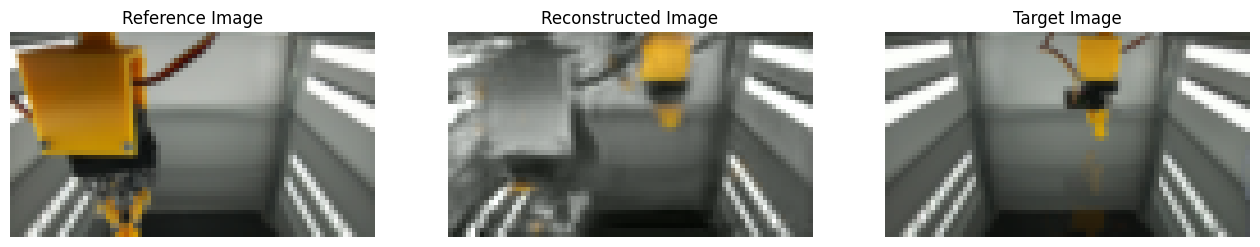

In [21]:
show_sample_reference_vs_reconstruction_vs_target(ref_test_dataset, unet_1ref_trainer, idx=8)

### cUNet with 10 references

In [22]:
MODEL_TO_LOAD = "unet_10ref_val10000_batch32_xyzrg"

In [23]:
# load model config
model_path = os.path.join(dir, decoder_type, MODEL_TO_LOAD)
config_file = os.path.join(dir, decoder_type, MODEL_TO_LOAD, "config.yaml")
with open(config_file, "r") as f:
    config = yaml.safe_load(f)

# load trained model
unet_10ref = UNetWithFiLM(
    model_name=MODEL_TO_LOAD,
    accelerator=accelerator,
    config=config, 
)
unet_10ref.load_model(model_path)
unet_10ref = accelerator.prepare(unet_10ref)
unet_10ref.eval()
unet_10ref_trainer = Trainer(unet_10ref, config)

Evaluation on test set

- original test set
- toy test set

In [41]:
print("Evaluation on test set:")
dataset_metrics = unet_10ref_trainer.evaluate_model(ref_test_loader)

print("\nEvaluation on test toy dataset")
toy_dataset_metrics = unet_10ref_trainer.evaluate_model(ref_toy_test_loader)

Evaluation on test set:


Test MSE loss: 0.0026
Test RMSE loss: 0.0515
Test LPIPS loss: 0.1429

Evaluation on test toy dataset


Test MSE loss: 0.0031
Test RMSE loss: 0.0559
Test LPIPS loss: 0.1475


Demo to visualize reference, reconstruction and target images $\newline$
on the test set of the clean environment dataset (used for training)

In [27]:
slider_reference_vs_reconstruction_vs_target(test_dataset_10ref, unet_10ref_trainer)

interactive(children=(IntSlider(value=0, description='idx', max=9999), Output()), _dom_classes=('widget-intera…

Demo to visualize reference, reconstruction and target images $\newline$
on the test set of the toy dataset (not used for training) with an object in the environment.

In [28]:
slider_reference_vs_reconstruction_vs_target(toy_test_dataset_10ref, unet_10ref_trainer)

interactive(children=(IntSlider(value=0, description='idx', max=299), Output()), _dom_classes=('widget-interac…

MSE loss: 0.0014
LPIPS loss: 0.0836
RMSE loss: 0.0370
Robot configuration x=0.207, y=0.507, z=0.128, r=0.594, g=0.567


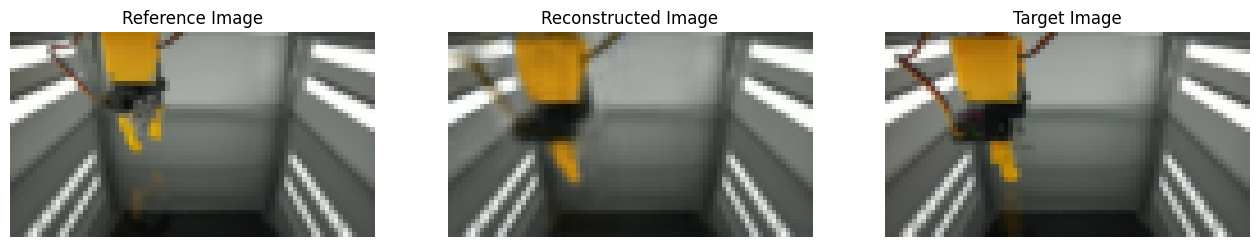

In [35]:
show_sample_reference_vs_reconstruction_vs_target(test_dataset_10ref, unet_10ref_trainer, idx=8)